In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import csv

from auxiliary import load_alternatives, load_criteria, load_criteria_definitions, load_value_functions
from pivotal_bwt import bwt
from up_mavt import mc_simulation
from aggregation_methods import weighted_sum
from weight_sampling import create_weight_samples


In [18]:

# Load data from weight elicitation
file_path_weight_elicitations = ["wbt_results_1.csv", "wbt_results_2.csv"]
# Value function files (one per elicitation / run)
file_path_value_functions = ["value_functions_1.csv", "value_functions_2.csv"]

# Load data of criteria definiton and value functions
# Not great that I have both definiton of criteria and value functions in the same file
# So here there should be a loading of the criteria definitions only
file_path_criteria = "criteria.csv"

# Load value functions - build a deterministic canonical order of criteria
# Load criteria once to establish canonical ordering (group order, then criterion order)
first_dict = load_criteria_definitions(file_path_criteria)
crit_names = [crit_name for group_data in first_dict.values() for crit_name in group_data['criteria'].keys()]
num_criteria = len(crit_names)

# mapping from criterion name to its index in crit_names
crit_index = {name: idx for idx, name in enumerate(crit_names)}

# Initialize list of lists: each index corresponds to a criterion in `crit_names`
vf_list = [[] for _ in range(num_criteria)]

# Build vf_list by reading the separate value function CSVs (one per elicitation)
for vp in file_path_value_functions:
    vf_map = load_value_functions(vp)
    for idx, crit_name in enumerate(crit_names):
        vf_list[idx].append(vf_map[crit_name])

# # Quick sanity-check: print one evaluation per criterion using the canonical min/max
# for idx, crit_name in enumerate(crit_names):
#     # retrieve min/max from the canonical (first) loaded dict
#     for group_data in first_dict.values():
#         if crit_name in group_data['criteria']:
#             crit_data = group_data['criteria'][crit_name]
#             min_val = crit_data['min_value']
#             max_val = crit_data['max_value']
#             break
#     vfs = vf_list[idx]
#     # print evaluation of the first value function for this criterion
#     print(f"Criterion {idx} ('{crit_name}'): ", vfs[0](min_val), vfs[0](max_val))
    
    
# Construct list of dict_data for each elicitation
# Load criteria.csv which contains only criteria definitions
# Adds info about value functions from vf_list for each elicitation
dict_data_list = []
for i, fp in enumerate(file_path_weight_elicitations):
    dict_data = load_criteria(file_path_criteria, fp)
    # attach value functions from the already-loaded vf_list for this elicitation index
    for gname, gdata in dict_data.items():
        for crit_name, crit in gdata['criteria'].items():
            idx = crit_index[crit_name]
            crit['value_function'] = vf_list[idx][i]
    dict_data_list.append(dict_data)

# Run BWT for each elicitation results
# and collect errors from the optimization problems
err_list = []
for i, dict_data in enumerate(dict_data_list):
    results = bwt(dict_data)
    err_list.append(results["z"])
   


Starting optimization...
Starting optimization...


In [19]:
# Initial point
initial_point = results["solver_result"]["x"]
known_max_error = results["z"]
print(f"Initial point: {initial_point}")
from pivotal_bwt import constraints_func
print(min(constraints_func(initial_point, dict_data, known_max_error)))

Initial point: [0.26319971 0.12496415 0.11265813 0.18367691 0.16701681 0.14973686
 0.99709969 0.99511687 0.        ]
0.0


In [20]:
tolerance = 1e-5
grid_size = 0.001  # Size of grid cells for exclusion zones
delta = grid_size * 1.1 # Step size

# Track valid and boundary points
valid_points = [initial_point]
boundary_points = []

# Grid to track used cells
used_cells = set()
used_cells.add(tuple((initial_point / grid_size).astype(int)))
i = 0
nx = int(np.ceil(1.0 / grid_size))
n_dimensions = len(initial_point)
total_cells = nx ** n_dimensions
from pivotal_bwt import constraints_func
max_iters = 1000
while i < max_iters and len(used_cells) < total_cells:
    i += 1
    # Randomly select a valid point to expand from
    x_a = valid_points[np.random.randint(len(valid_points))]
    y_a = min(constraints_func(x_a, dict_data,known_max_error)[0:5])

    # Generate a random direction
    direction = np.random.randn(n_dimensions)
    direction = direction / np.linalg.norm(direction)
    x_b = x_a + delta * direction
    x_b = np.clip(x_b, 0, 1)  # Ensure x_b is in [0, 1]
    y_b = min(constraints_func(x_b, dict_data,known_max_error)[0:5])

    j = 0
    while abs(y_b) > tolerance and j < 1000:
        j += 1
        if y_b < 0:  # b is invalid
            # Move toward a
            direction = x_a - x_b
            norm = np.linalg.norm(direction)
            if norm == 0:
                break
            direction = direction / norm
            new_modulus = abs(y_a) / (abs(y_b - y_a) + 1e-10)
            x_b = x_a + direction * new_modulus
            x_b = np.clip(x_b, 0, 1)
            y_b = min(constraints_func(x_b, dict_data,known_max_error)[0:5])
        else:  # b is valid
            # Add to valid points if not in a used cell (clamp index at grid edges)
            cell_idx = (x_b / grid_size).astype(int)
            cell_idx = np.minimum(cell_idx, np.full(n_dimensions, nx - 1, dtype=int))
            cell = tuple(cell_idx)
            if cell not in used_cells:
                valid_points.append(x_b.copy())
                used_cells.add(cell)
            # Move further in the same direction
            x_b = x_b + delta * direction
            x_b = np.clip(x_b, 0, 1)
            y_b = min(constraints_func(x_b, dict_data, known_max_error)[0:5])

    if j < 1000:
        boundary_points.append(x_b.copy())

c:\Users\Simo\Documents\GitHub\Master-Thesis\Complete Test\pivotal_bwt.py:45: RuntimeWarning: divide by zero encountered in scalar divide
  cons.append(z - abs(v_f_other(value) - w[i] / w[j]))
c:\Users\Simo\Documents\GitHub\Master-Thesis\Complete Test\pivotal_bwt.py:38: RuntimeWarning: divide by zero encountered in scalar divide
  cons.append(z - abs(w[i] / w[j] - 1 / v_f_other(value)))
c:\Users\Simo\Documents\GitHub\Master-Thesis\Complete Test\pivotal_bwt.py:45: RuntimeWarning: invalid value encountered in scalar divide
  cons.append(z - abs(v_f_other(value) - w[i] / w[j]))
c:\Users\Simo\Documents\GitHub\Master-Thesis\Complete Test\pivotal_bwt.py:38: RuntimeWarning: invalid value encountered in scalar divide
  cons.append(z - abs(w[i] / w[j] - 1 / v_f_other(value)))


In [23]:
print(f"Found {len(used_cells)} cells (valid points) out of {total_cells:.1e} total cells.")

Found 307186 cells (valid points) out of 1.0e+27 total cells.


In [24]:
# Plot histogram of the occurencices of the first 6 dimensions
# valid_points is a matrix of n_dimensions columns, i want an histogram per column
# only for the first 6 dimensions (0 to 5)
valid_points = np.array(valid_points)
print(valid_points.shape)
n_bins = int(1.0 / grid_size)
print(n_bins)

(307186, 9)
1000


In [40]:
double_checked_points = []
for v_p in valid_points:
    if sum(v_p[0:(num_criteria-1)]) <= 1:
        double_checked_points.append(v_p)
print(len(double_checked_points))

196752


In [43]:
# save in a csv with columns Criterion_1,Criterion_2,Criterion_3,Criterion_4,Criterion_5,Criterion_6
with open("valid_points.csv", mode='w', newline='') as file:
    writer = csv.writer(file)
    # Write header
    header = [f"Criterion_{i+1}" for i in range(n_dimensions)]
    writer.writerow(header)
    # Write data
    for point in double_checked_points:
        writer.writerow(point)

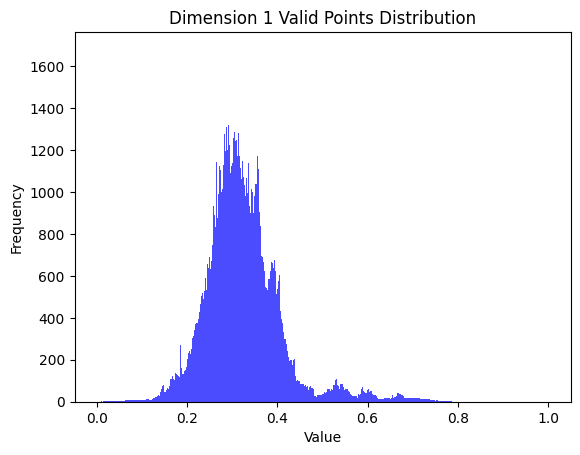

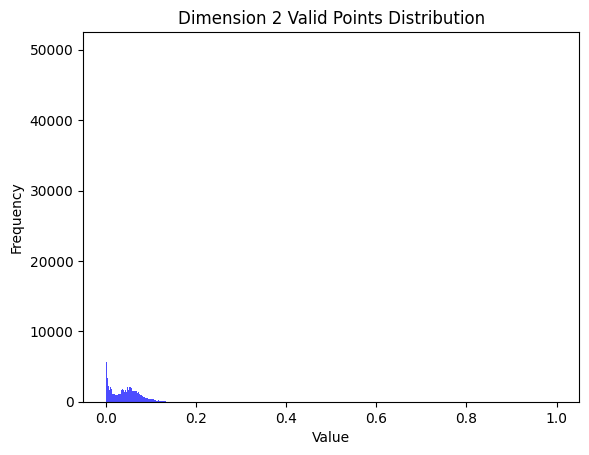

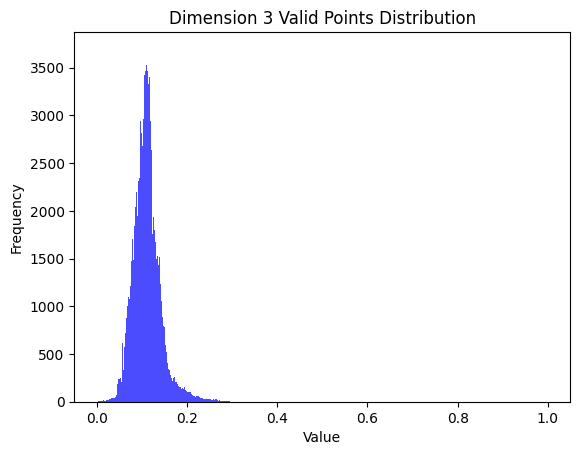

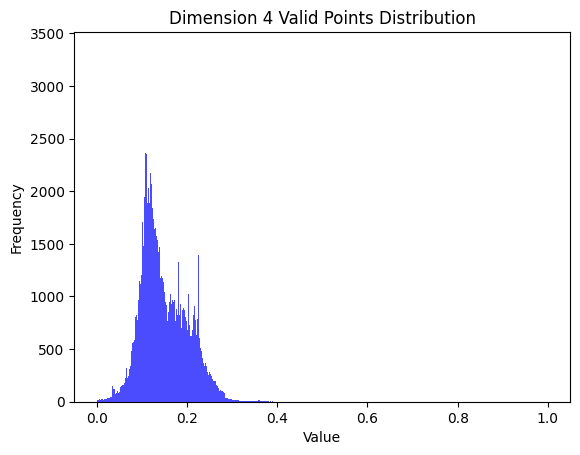

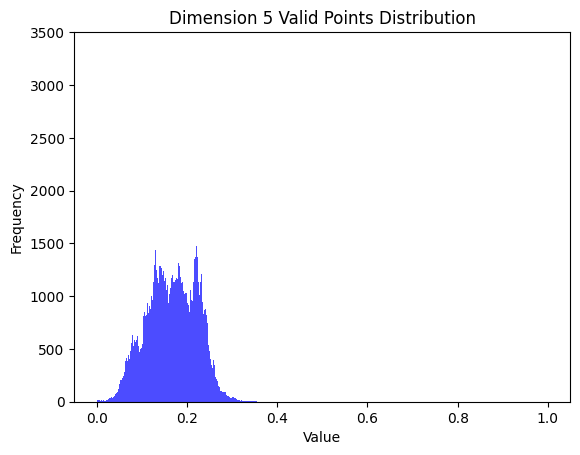

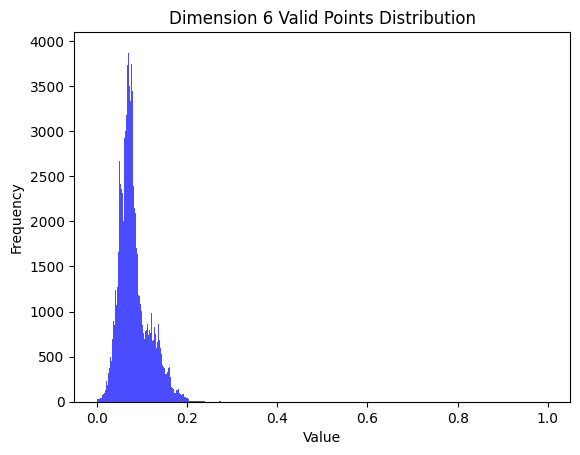

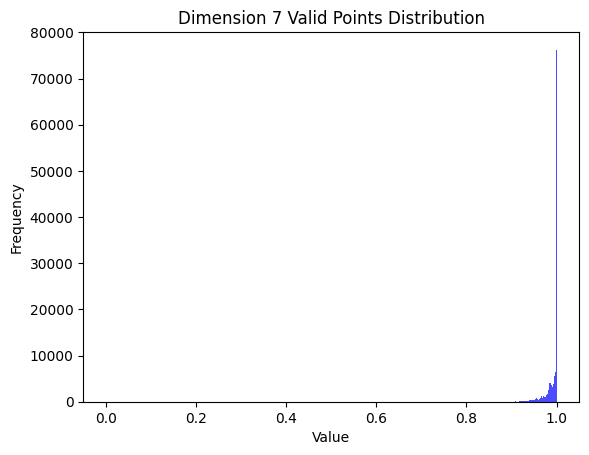

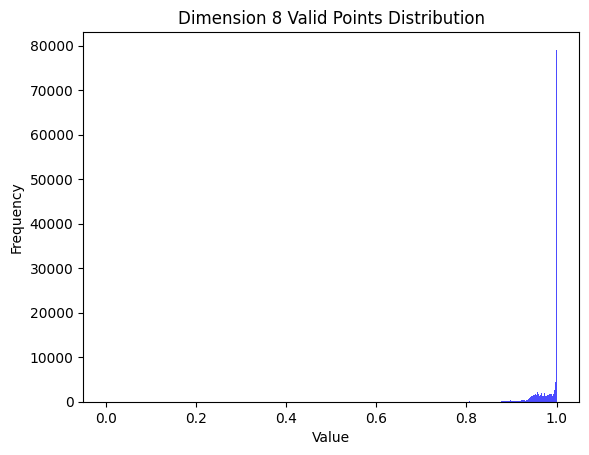

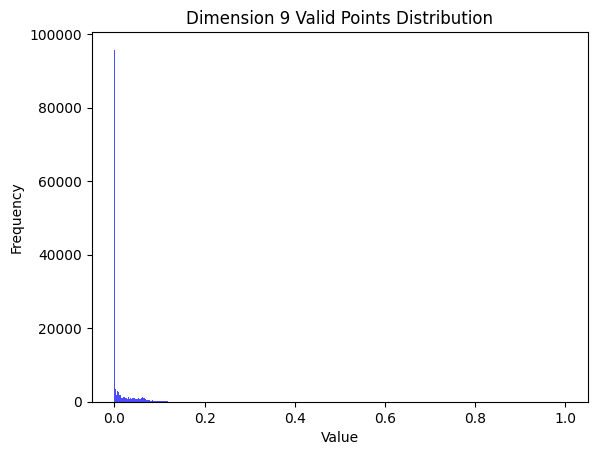

In [41]:
for dim in range(n_dimensions):
    plt.hist(np.array(double_checked_points)[:, dim], bins=n_bins, range=(0, 1), color='blue', alpha=0.7)
    plt.title(f"Dimension {dim+1} Valid Points Distribution")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.show()